<div style="
    font-family: 'Georgia', 'Times New Roman', serif;
    background: #ffffff;
    color: #2d3748;
    padding: 34px 40px;
    margin: 30px 0;
    border: 4px solid #e2e8f0;
    border-top: 6px solid #4a5568;
    border-radius: 12px;
    box-shadow: 0 8px 25px rgba(0, 0, 0, 0.08);
    line-height: 1.8;
">

# Классификация типов сигнала

# Описание проекта
Современные задачи ядерной энергетики, радиационного контроля, фундаментальной и прикладной физики требуют высокоточной регистрации и анализа излучения различной природы. Важной составляющей этих задач является возможность отделения компонентов ионизирующего излучения, таких как гамма-кванты и нейтроны, в условиях сложного фонового окружения.

# Цель работы
Автоматическая кластеризация сигналов, полученных со сцинтилляционного детектора, на основе их параметров. Необходимо разделить 23 479 сигналов на три кластера: два из них соответствуют различным типам частиц (гамма-кванты и нейтроны), а третий — группе аномальных или неидентифицируемых сигналов.

# Результат:
 **SCORE=** 0.76012

# Ход работы
[1. **Импорт библиотек, загрузка данных.**:](#1-bullet)

[2. **EDAх**:](#2-bullet)

[2.2.Промежуточный вывод](#3-bullet)

[3. **Предобработка данных:**:](#4-bullet)

[3.1.Промежуточный вывод](#5-bullet)

[4. **FEATURE ENGINEERING**:](#6-bullet)

[4.1 Промежуточный вывод:](#7-bullet)

[5.**Сравнение сетов признаков и выбор оптимальной модели:**](#8-bullet)

[5.1. Промежуточный вывод](#9-bullet)

[6. **Результат:**](#10-bullet)

[8. **Финальный вывод**](#11-bullet)
</div>

<a class="anchor" id="1-bullet"></a> 
# Импорт библиотек, загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import skew, median_abs_deviation
from itertools import permutations
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)

<a class="anchor" id="2-bullet"></a> 
# EDA

In [2]:
pd.set_option('display.max_columns', None)
display(df.head(5))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,14820,14822,14824,14820,14828,14819,14822,14822,14820,14822,14820,14819,14820,14821,14815,14830,14824,14825,14820,14820,14824,14822,14817,14825,14820,14814,14822,14823,14824,14820,14820,14823,14822,14817,14824,14826,14823,14822,14818,14822,14820,14817,14820,14821,14822,14820,14818,14820,14820,14825,14818,14819,14824,14822,14818,14820,14827,14826,14824,14819,14820,14822,14820,14820,14822,14825,14822,14821,14817,14822,14819,14821,14823,14821,14817,14820,14827,14820,14820,14823,14820,14815,14820,14822,14820,14824,14817,14818,14819,14822,14819,14818,14827,14820,14818,14820,14819,14818,14820,14824,14822,14820,14817,14822,14820,14817,14824,14822,14823,14824,14820,14825,14818,14823,14817,14820,14824,14824,14815,14820,14820,14822,14817,14822,14820,14820,14820,14822,14820,14819,14818,14823,14818,14818,14820,14814,14763,14563,14378,14291,14378,14460,14532,14607,14630,14681,14732,14741,14748,14756,14772,14779,14790,14792,14799,14801,14799,14797,14792,14803,14798,14794,14794,14814,14808,14811,14810,14807,14815,14810,14807,14801,14804,14804,14801,14801,14810,14806,14791,14813,14799,14802,14804,14811,14812,14803,14803,14812,14816,14819,14812,14809,14817,14817,14815,14817,14820,14817,14812,14816,14819,14816,14815,14822,14806,14817,14809,14813,14810,14813,14812,14819,14812,14815,14812,14823,14810,14810,14819,14819,14822,14813,14816,14820,14816,14817,14820,14819,14817,14821,14820,14826,14819,14820,14820,14826,14819,14821,14812,14820,14817,14813,14812,14815,14815,14814,14817,14817,14817,14815,14814,14820,14815,14813,14810,14820,14822,14821,14818,14818,14819,14820,14812,14818,14820,14816,14818,14819,14817,14819,14820,14816,14817,14816,14819,14819,14818,14818,14817,14820,14818,14824,14823,14813,14817,14818,14815,14825,14819,14827,14818,14815,14820,14823,14815,14822,14827,14822,14818,14818,14818,14822,14812,14830,14819,14817,14823,14828,14824,14810,14817,14827,14823,14814,14820,14821,14820,14816,14818,14828,14818,14822,14819,14823,14817,14816,14824,14822,14823,14818,14822,14825,14820,14823,148

In [3]:
print("Размер",df.shape)

Размер (23479, 505)


In [4]:
print(f"Пропусков:",df.isnull().sum().sum(), "Дубликатов:",df.duplicated().sum())

Пропусков: 23479 Дубликатов: 0


In [5]:
display(df.describe())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504
count,2.347900e+04,23479.000000,23479.000000,23479.0,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.00000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.00000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.00000,23479.000000,23479.000000,23479.000000,23479.00000

In [6]:
signal_data = df.iloc[:, 4:504].values
print("Диапазон значений:", signal_data.min(), signal_data.max())
print("Среднее:", signal_data.mean())
print("Стандартное отклонение:", signal_data.std())

Диапазон значений: 0 14838
Среднее: 14796.683723582775
Стандартное отклонение: 265.9150654051666


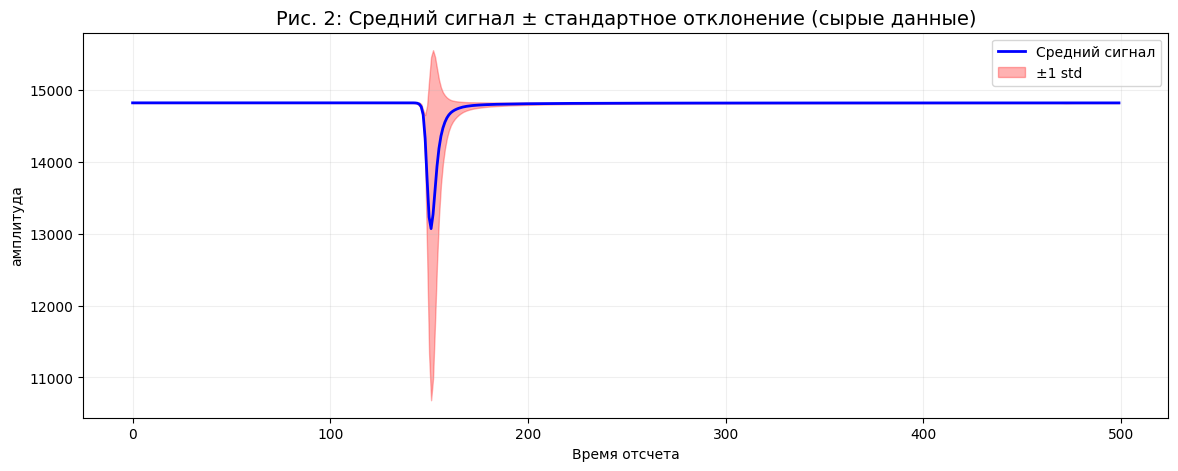

In [7]:
raw_signals = df.iloc[:, 4:504].values
mean_raw = raw_signals.mean(axis=0)
std_raw = raw_signals.std(axis=0)

plt.figure(figsize=(14, 5))
plt.plot(mean_raw, 'b-', linewidth=2, label='Средний сигнал')
plt.fill_between(range(500), mean_raw-std_raw, mean_raw+std_raw,
                 alpha=0.3, color='red', label='±1 std')
plt.xlabel('Время отсчета')
plt.ylabel('амплитуда')
plt.title('Рис. 2: Средний сигнал ± стандартное отклонение (сырые данные)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


<Figure size 2000x1000 with 0 Axes>

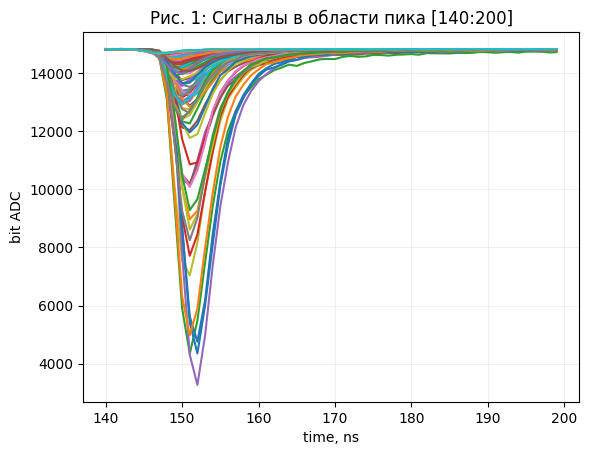

In [8]:
dataset = df.drop([0, 1, 2, 3, 504], axis=1)  # временно для графика
dataset.columns = list(range(500))

N = range(0, 100)
plt.figure(figsize=(20, 10))
ax = dataset.T[N][140:200].plot(title='Рис. 1: Сигналы в области пика [140:200]', legend=None)
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")
plt.grid(True, alpha=0.2)
plt.show()

<a class="anchor" id="3-bullet"></a> 
# Промежуточный вывод:
Загружен датасет в котором находятся 23479 сигнала и 500 временных отсчетов (колонку 0-3 и 504 )не считаем.Выявлены пропуски, решим что с ними делать на следующем этапе.Дубликатов нет.Данные имеют четкую форму базовая линия- провал - базовая линия(есть смысл обрезать шум).Амплитуда в провале разная, тк частицы обладают разной энергией.

<a class="anchor" id="4-bullet"></a> 
# Предобработка данных:

In [9]:
dataset = df.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
print("После удаления колоно 0-4 и 504:", dataset.shape)

После удаления колоно 0-4 и 504: (23479, 500)


In [10]:
signals = 2**14 - dataset.values - 1560

инвертировал

In [11]:
S = signals[:, 140:200]
print(f"Рабочая область [140-200]: {S.shape}")

Рабочая область [140-200]: (23479, 60)


Как подметил на EDA, выделю себе область для того что бы отбросить лишний шум.

In [12]:
print("Пропусков[140:200]:", np.isnan(S).sum())

Пропусков[140:200]: 0


<a class="anchor" id="5-bullet"></a> 
# Промежуточный вывод
удалил служебные колонки,инвертировал сигналы и выделил себе область. Обрабатывать пропуски не пришлось

<a class="anchor" id="6-bullet"></a> 
# FEATURE ENGINEERING

In [13]:
n = len(S)
peak_amp = S.max(axis=1)
peak_pos = S.argmax(axis=1)
total_charge = S.sum(axis=1)
tail_charge = np.array([S[i, peak_pos[i]+3:].sum() for i in range(n)])
psd = tail_charge / (total_charge + 1e-9)
half_max = peak_amp / 2
peak_sharpness = (S > half_max[:, None]).sum(axis=1)
baseline_std_raw = S[:, :5].std(axis=1)
decay_time = []
for i in range(n):
    after = S[i, peak_pos[i]:]
    idx = np.where(after < 0.1 * peak_amp[i])[0]
    decay_time.append(idx[0] if len(idx) > 0 else 80)
decay_time = np.array(decay_time)
skewness_val = np.array([skew(S[i]) for i in range(n)])
area_peak_arr = np.array([S[i, :peak_pos[i]].sum() for i in range(n)])
area_decay_arr = np.array([S[i, peak_pos[i]:].sum() for i in range(n)])
area_ratio_val = area_peak_arr / (area_decay_arr + 1e-9)
mad_val = np.array([median_abs_deviation(S[i]) for i in range(n)])
zero_cross_val = np.array([np.sum(np.diff(np.signbit(S[i] - np.mean(S[i])))) for i in range(n)])

извлек признаки и дальше обработаю

In [14]:
p99 = np.percentile(baseline_std_raw, 99)
baseline_std = np.clip(baseline_std_raw, 0, p99)
peak_amplitude_log = np.log1p(peak_amp)
tail_to_peak = tail_charge / (peak_amp + 1e-9)
tail_to_peak_log = np.log1p(tail_to_peak)
skewness_val = np.array([skew(S[i]) for i in range(n)])
area_peak_arr = np.array([S[i, :peak_pos[i]].sum() for i in range(n)])
area_decay_arr = np.array([S[i, peak_pos[i]:].sum() for i in range(n)])
area_ratio_val = area_peak_arr / (area_decay_arr + 1e-9)
mad_val = np.array([median_abs_deviation(S[i]) for i in range(n)])
zero_cross_val = np.array([np.sum(np.diff(np.signbit(S[i] - np.mean(S[i])))) for i in range(n)])

Соберу признаки после обработки затем посмотрим матрицу кореляций

In [15]:
features_all = pd.DataFrame({
    'psd': psd,
    'peak_amplitude': peak_amplitude_log,
    'decay_time': decay_time,
    'peak_sharpness': peak_sharpness,
    'tail_to_peak_log': tail_to_peak_log,
    'baseline_std': baseline_std,
    'skewness': skewness_val,
    'area_ratio': area_ratio_val,
    'mad': mad_val,
    'zero_cross': zero_cross_val,
})

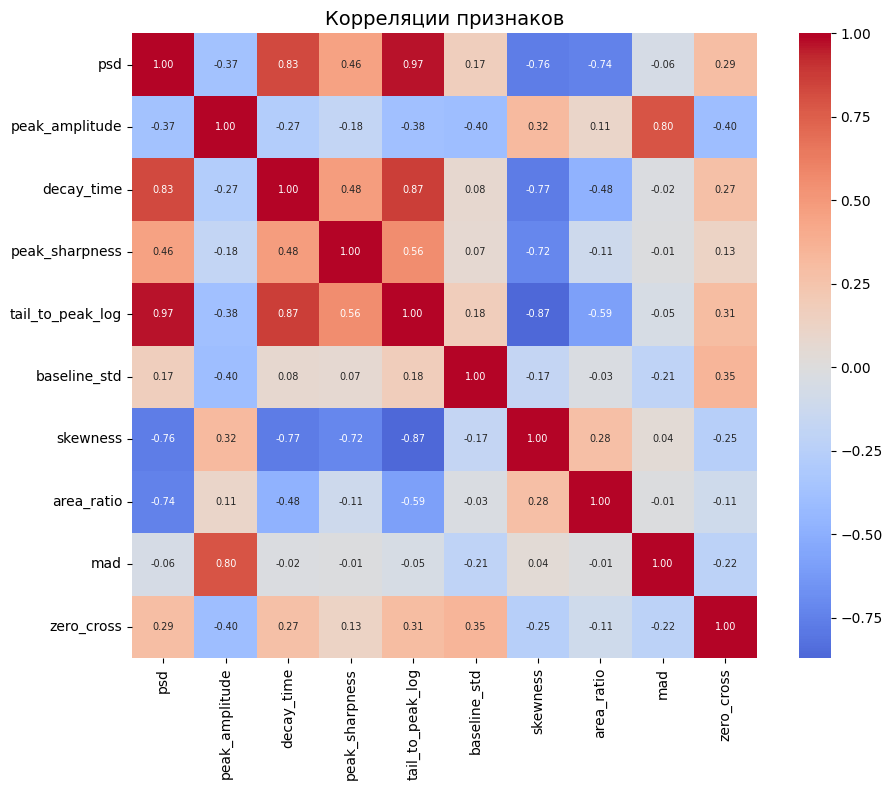

In [16]:
plt.figure(figsize=(10, 8))
corr_all = features_all.corr()
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, annot_kws={'size': 7})
plt.title('Корреляции признаков', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
feature_sets = {
    '10 (все признаки)': [
        'psd','peak_amplitude','decay_time','peak_sharpness','tail_to_peak_log',
        'baseline_std','skewness','area_ratio','mad','zero_cross'],
    '9 (без mad)': [
        'psd','peak_amplitude','decay_time','peak_sharpness','tail_to_peak_log',
        'baseline_std','skewness','area_ratio','zero_cross'],
    '9 (без zero_cross)': [
        'psd','peak_amplitude','decay_time','peak_sharpness','tail_to_peak_log',
        'baseline_std','skewness','area_ratio','mad'],
    '8 (оптимальный)': [
        'psd','peak_amplitude','decay_time','peak_sharpness','tail_to_peak_log',
        'baseline_std','skewness','area_ratio'],
    '8 (без psd)': [
        'peak_amplitude','decay_time','peak_sharpness','tail_to_peak_log',
        'baseline_std','skewness','area_ratio','mad','zero_cross'],
    '8 (без tail_to_peak_log)': [
        'psd','peak_amplitude','decay_time','peak_sharpness',
        'baseline_std','skewness','area_ratio','mad','zero_cross'],
    '7 (без mad, zero_cross, tail_to_peak_log)': [
        'psd','peak_amplitude','decay_time','peak_sharpness',
        'baseline_std','skewness','area_ratio'],
}

<a class="anchor" id="7-bullet"></a> 
# Промежуточный вывод:
на данном этапе извлек 10 признаков( те которые предлагались в документе к работе и обозначил свои)
  * psd -отношение хвост/полный заряд
  * skewness — асимметрия сигнала
  * decay_time -время спада до 10% от максимума
  * mad —медианное абсолютное отклонение
  * peak_amplitude - логарифм амплитуды (энергия частицы)
  * peak_sharpness — ширина пика на полувысоте
  * tail_to_peak_log — ормированный хвост
  * baseline_std — уровень шума
  * area_ratio — отношение площади до/после пика
  * zero_cross — число пересечений среднего уровня

В обработке использовал логарифмирование и обрезал выбросы по 99%
Сделал себе сеты для проверки признаков.

<a class="anchor" id="8-bullet"></a> 
# Сравнение сетов признаков и выбор оптимальной модели:

In [18]:
best_sil = 0
best_name = ""
best_cols = None

for name, cols in feature_sets.items():
    X_test = StandardScaler().fit_transform(features_all[cols])
    labels_test = KMeans(n_clusters=3, random_state=42, n_init=20).fit_predict(X_test)
    sil = silhouette_score(X_test, labels_test, sample_size=5000, random_state=42)
    if sil > best_sil:
        best_sil = sil
        best_name = name
        best_cols = cols
    print(f"{name:35s}: {sil:.4f}")


10 (все признаки)                  : 0.2605
9 (без mad)                        : 0.3241
9 (без zero_cross)                 : 0.2933
8 (оптимальный)                    : 0.3751
8 (без psd)                        : 0.2528
8 (без tail_to_peak_log)           : 0.2460
7 (без mad, zero_cross, tail_to_peak_log): 0.3437


Победитель очевиден, определяем лучший набор и сравниваем модели на нем 

In [19]:
best_cols = ['psd', 'peak_amplitude', 'decay_time', 'peak_sharpness',
             'tail_to_peak_log', 'baseline_std', 'skewness', 'area_ratio']
features = features_all[best_cols]
X_scaled = StandardScaler().fit_transform(features)

In [20]:
labels_km = KMeans(n_clusters=3, random_state=42, n_init=20).fit_predict(X_scaled)
sil_km = silhouette_score(X_scaled, labels_km, sample_size=5000, random_state=42)
unique_km, counts_km = np.unique(labels_km, return_counts=True)
print("Силуэт:",sil_km)
print(f"Кластеры: {dict(zip(unique_km, counts_km))}")

Силуэт: 0.375113018845517
Кластеры: {np.int32(0): np.int64(12234), np.int32(1): np.int64(10114), np.int32(2): np.int64(1131)}


In [21]:
for eps in [0.3, 0.5, 0.8, 1.0]:
    for ms in [5, 10, 15]:
        labels_db = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        n_clusters = len(np.unique(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = np.sum(labels_db == -1)
        
        if n_clusters >= 2:
            mask = labels_db != -1
            sil_db = silhouette_score(X_scaled[mask], labels_db[mask], sample_size=5000, random_state=42)
            if 2 <= n_clusters <= 4:
                print(f"  eps={eps}, ms={ms:2d}: кластеров={n_clusters}, "
                      f"шум={n_noise} ({n_noise/len(labels_db)*100:.1f}%), силуэт={sil_db:.4f}")
print("Не определил 3 кластера , каак нам необходимо по заданию")

Не определил 3 кластера , каак нам необходимо по заданию


**Победитель ниже**

In [22]:
labels = labels_km
sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)

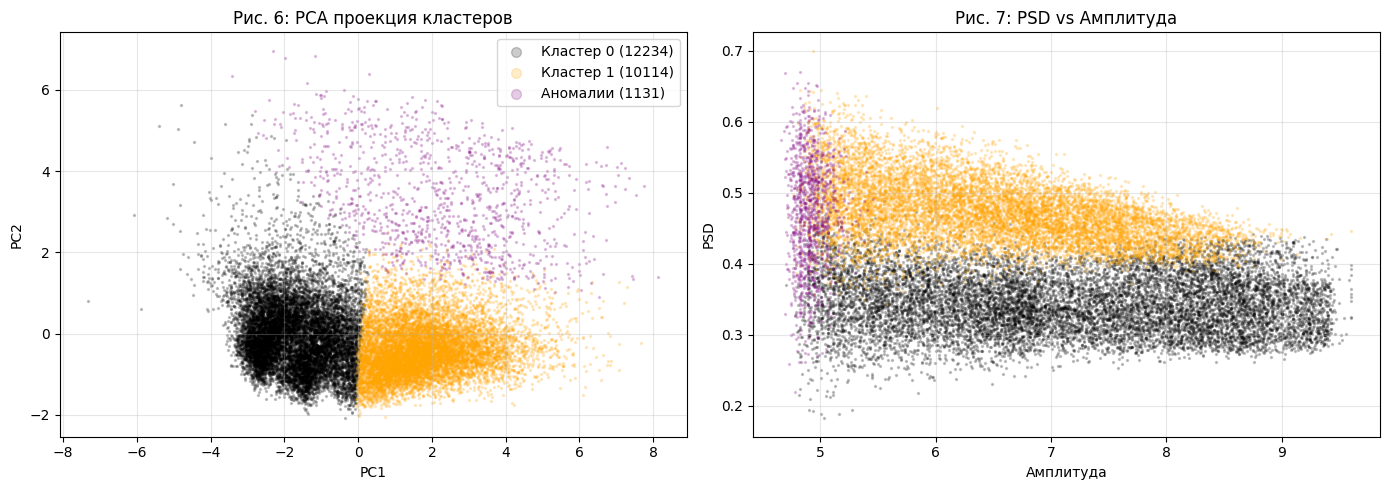

In [23]:
X_pca = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_names = {0: 'Кластер 0', 1: 'Кластер 1', 2: 'Аномалии'}
colors = ['black', 'orange', 'purple']

for i in range(3):
    mask = labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i], alpha=0.2, s=2,
                    label=f'{cluster_names[i]} ({mask.sum()})')
axes[0].set_title('Рис. 6: PCA проекция кластеров', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=5)
axes[0].grid(True, alpha=0.3)

for i in range(3):
    mask = labels == i
    axes[1].scatter(features['peak_amplitude'][mask],
                    features['psd'][mask],
                    c=colors[i], alpha=0.2, s=2)
axes[1].set_title('Рис. 7: PSD vs Амплитуда', fontsize=12)
axes[1].set_xlabel('Амплитуда')
axes[1].set_ylabel('PSD')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a class="anchor" id="9-bullet"></a> 
# Промежуточныый вывод
Определил лучший сет с помощью kmeans и силуэта, взял оптимальный набор из подготовленных, как лучший. На этом наборе признаков kmeans показал результат 0.37. Dbscan  с задачей не справился , тк наша цель определить 3 кластера. Финалист kmeans

<a class="anchor" id="10-bullet"></a> 
# Результат:

In [24]:
mapping = {0: 1, 1: 0, 2: 2}
labels_remapped = [mapping[l] for l in labels]

pd.DataFrame({
    'index': range(len(labels_remapped)),
    'cluster': labels_remapped
}).to_csv('submission.csv', index=False)

подготовил сразу рабочую перестановку.

<a class="anchor" id="11-bullet"></a> 
# Финальный вывод:

В процессе проекта были проделаны стадии: загрузки данных, проведен EDA, выполнена предабработка данных, извлечены признаки, как те что рекомендовались в пособии так и свои, к признакам была применена обрабока данных, log и обрезание выборосов.Посмотрев на матрицу я решил сделать 7 сетов которые в последствии протестировал на kmeans и отобрал лучший сет по силуэту.Были сравнены 2 модели Kmeans и DBSCAN, последний не дал результатов и по этому беззаговорочным победителем в этой дуэли стал kmeans. Чемпион выделил 3 кластера: (12234),(10114),(1131).Опытным путем перебрал sub и вывел для проверки рабочую перестановку. **score** = 0.76012

Что выделил для себя?: на мой взгляд результат достигнут блягодаря выделению области пика и отличному подбору признаков.

P.S. результат проверен - воспроизводим